# BUSI Dataset – Depthwise Separable CNN

Same dataset, same training pipeline, same imbalance strategies as the baseline notebook.  
Architecture replaces every standard Conv2d with a **Depthwise Separable Convolution** (depthwise + pointwise) to reduce parameters while maintaining representational capacity.

In [1]:
!pip install kaggle torch torchvision --quiet

In [2]:
!kaggle datasets download subhajournal/busi-breast-ultrasound-images-dataset --quiet

Dataset URL: https://www.kaggle.com/datasets/subhajournal/busi-breast-ultrasound-images-dataset
License(s): GNU Free Documentation License 1.3


## 1. Dataset Loading & Exploration

Class distribution:
  benign      : 437 (56.0%)
  malignant   : 210 (26.9%)
  normal      : 133 (17.1%)


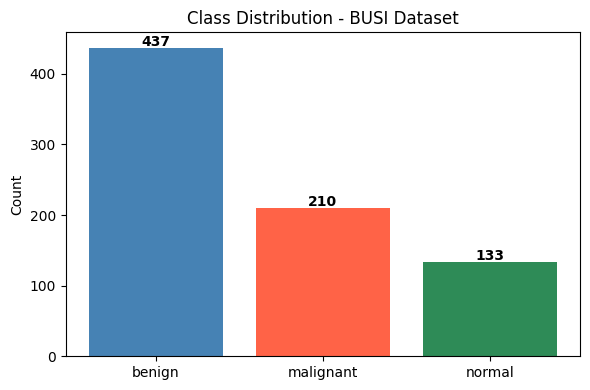

In [3]:
import os, zipfile
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

if os.path.exists('busi-breast-ultrasound-images-dataset.zip'):
    with zipfile.ZipFile('busi-breast-ultrasound-images-dataset.zip') as z:
        z.extractall('.')

dataset_folder = next(d for d in os.listdir('.') if os.path.isdir(d) and 'BUSI' in d.upper())
classes = sorted(d for d in os.listdir(dataset_folder) if os.path.isdir(os.path.join(dataset_folder, d)))

def get_imgs(cls):
    p = os.path.join(dataset_folder, cls)
    return [f for f in os.listdir(p) if f.lower().endswith(('.png','.jpg','.jpeg','.bmp')) and '_mask' not in f]

class_counts_dict = {c: len(get_imgs(c)) for c in classes}
total = sum(class_counts_dict.values())
print('Class distribution:')
for c, n in class_counts_dict.items():
    print(f'  {c:12s}: {n} ({100*n/total:.1f}%)')

plt.figure(figsize=(6,4))
plt.bar(class_counts_dict.keys(), class_counts_dict.values(), color=['steelblue','tomato','seagreen'])
plt.title('Class Distribution - BUSI Dataset'); plt.ylabel('Count')
for i,(c,n) in enumerate(class_counts_dict.items()): plt.text(i, n+3, str(n), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

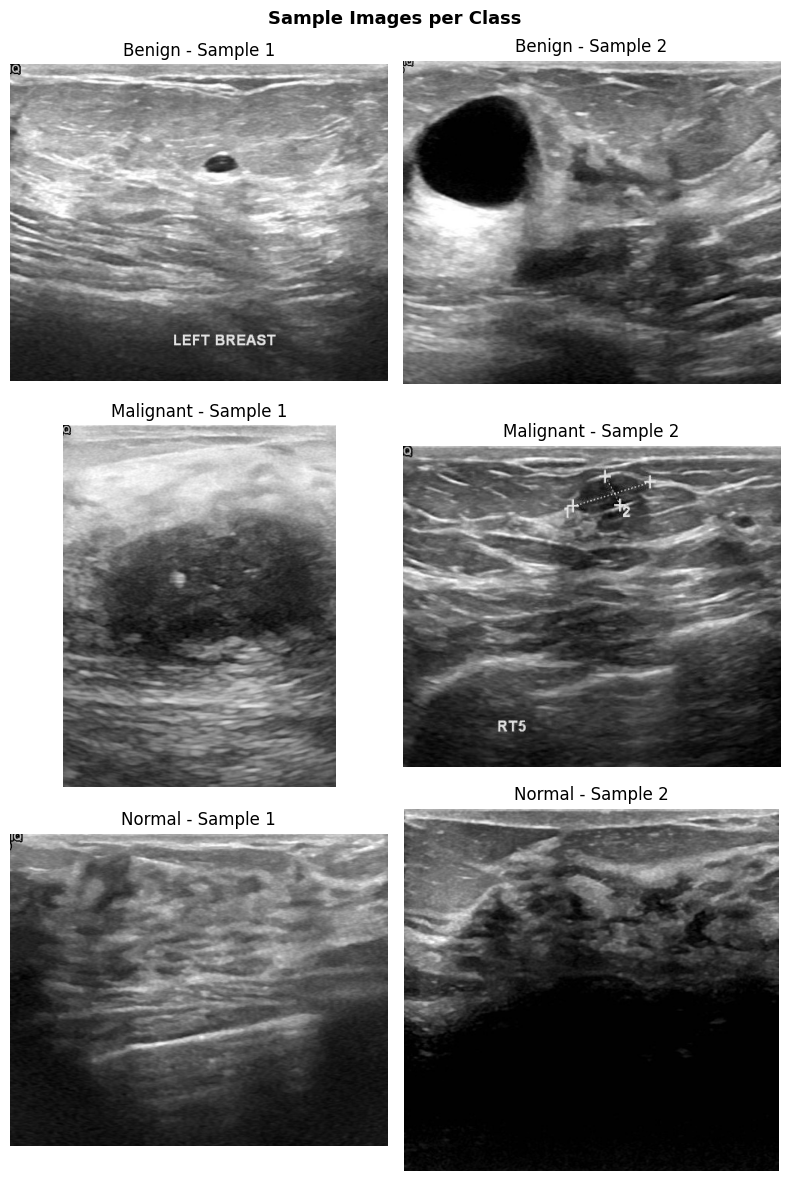

In [4]:
fig, axes = plt.subplots(len(classes), 2, figsize=(8, 4*len(classes)))
for ci, cls in enumerate(classes):
    for j, fname in enumerate(get_imgs(cls)[:2]):
        img = mpimg.imread(os.path.join(dataset_folder, cls, fname))
        axes[ci,j].imshow(img, cmap='gray')
        axes[ci,j].set_title(f'{cls.capitalize()} - Sample {j+1}')
        axes[ci,j].axis('off')
plt.suptitle('Sample Images per Class', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 2. Model & Data Setup

### Depthwise Separable Convolution

A standard convolution with kernel `k`, `C_in` input channels, and `C_out` output channels costs:

$$\text{Params}_{\text{std}} = k^2 \cdot C_{\text{in}} \cdot C_{\text{out}}$$

A **depthwise separable** block splits this into two steps:
1. **Depthwise conv** – one filter per channel: $k^2 \cdot C_{\text{in}}$
2. **Pointwise conv** (1×1) – mixes channels: $C_{\text{in}} \cdot C_{\text{out}}$

Total: $k^2 \cdot C_{\text{in}} + C_{\text{in}} \cdot C_{\text{out}}$, which is ~**8-9× fewer parameters** for 3×3 convolutions.

In [5]:
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_recall_fscore_support,
                              precision_score, recall_score, f1_score)
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import pandas as pd, warnings
warnings.filterwarnings('ignore')

IMG_SIZE = (128, 128)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

image_paths, labels = [], []
for cls in classes:
    for fname in get_imgs(cls):
        image_paths.append(os.path.join(dataset_folder, cls, fname))
        labels.append(cls)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)

train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
print(f'Train: {len(train_labels)} | Test: {len(test_labels)}')
print(f'Test distribution: {np.bincount(test_labels)} -> {list(label_encoder.classes_)}')

Device: cpu
Train: 624 | Test: 156
Test distribution: [87 42 27] -> [np.str_('benign'), np.str_('malignant'), np.str_('normal')]


In [6]:
# ── Dataset & DataLoader ──────────────────────────────────────────────────────
class BUSIDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths, self.labels, self.transform = paths, labels, transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert('L')
            return (self.transform(img) if self.transform else img), self.labels[idx]
        except:
            return torch.zeros(1, *IMG_SIZE), self.labels[idx]

def make_loader(paths, labels, sampler=None, augment=False, batch_size=32):
    t = [transforms.Resize(IMG_SIZE)]
    if augment:
        t += [transforms.RandomHorizontalFlip(), transforms.RandomRotation(10),
              transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8,1.0))]
    t += [transforms.ToTensor(), transforms.Normalize([0.5],[0.5])]
    ds = BUSIDataset(paths, labels, transforms.Compose(t))
    return DataLoader(ds, batch_size=batch_size, shuffle=(sampler is None), sampler=sampler, num_workers=0)

# ── Depthwise Separable Block ────────────────────────────────────────────────
class DepthwiseSeparableConv(nn.Module):
    """Depthwise conv (groups=C_in) followed by pointwise conv (1x1)."""
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.depthwise  = nn.Conv2d(in_channels, in_channels, kernel_size,
                                    padding=padding, groups=in_channels, bias=False)
        self.pointwise  = nn.Conv2d(in_channels, out_channels, 1, bias=False)
        self.bn         = nn.BatchNorm2d(out_channels)
    def forward(self, x):
        return F.relu(self.bn(self.pointwise(self.depthwise(x))))

# ── Depthwise Separable CNN ──────────────────────────────────────────────────
class DSConvCNN(nn.Module):
    """Same topology as SimpleCNN but uses DepthwiseSeparableConv blocks."""
    def __init__(self, nc):
        super().__init__()
        # First layer: standard conv (no depthwise on 1-channel input – nothing to separate)
        self.entry = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.ds1 = nn.Sequential(DepthwiseSeparableConv(32, 64), nn.MaxPool2d(2))
        self.ds2 = nn.Sequential(DepthwiseSeparableConv(64, 128), nn.MaxPool2d(2))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, nc))
    def forward(self, x):
        return self.head(self.ds2(self.ds1(self.entry(x))))

# ── Baseline SimpleCNN (for comparison) ─────────────────────────────────────
class SimpleCNN(nn.Module):
    def __init__(self, nc):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(128*16*16,128),
                                   nn.ReLU(), nn.Dropout(0.5), nn.Linear(128,nc))
    def forward(self, x): return self.head(self.net(x))

# ── Focal Loss ───────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0): super().__init__(); self.gamma=gamma
    def forward(self, inp, tgt):
        lp = F.log_softmax(inp,1); pt = torch.exp(lp).gather(1,tgt.unsqueeze(1)).squeeze(1)
        return (-((1-pt)**self.gamma) * lp.gather(1,tgt.unsqueeze(1)).squeeze(1)).mean()

# ── Helpers ──────────────────────────────────────────────────────────────────
def count_params(model):
    total   = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def train_model(model, loader, criterion, optimizer, epochs):
    model.train()
    for ep in range(epochs):
        loss_sum, correct, n = 0, 0, 0
        for imgs, tgts in loader:
            imgs, tgts = imgs.to(device), tgts.to(device)
            optimizer.zero_grad(); out = model(imgs); loss = criterion(out, tgts)
            loss.backward(); optimizer.step()
            loss_sum += loss.item()*imgs.size(0)
            correct  += (out.argmax(1)==tgts).sum().item()
            n        += imgs.size(0)
        print(f'  Ep {ep+1}/{epochs}  loss={loss_sum/n:.4f}  acc={correct/n:.4f}')

def eval_model(model, loader):
    model.eval(); yt, yp = [], []
    with torch.no_grad():
        for imgs, tgts in loader:
            yt.extend(tgts.numpy())
            yp.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
    return np.array(yt), np.array(yp)

def plot_cm(cm, title):
    fig, ax = plt.subplots(figsize=(6,4)); im = ax.matshow(cm, cmap='Blues'); fig.colorbar(im)
    ax.set_xticks(range(num_classes)); ax.set_yticks(range(num_classes))
    ax.set_xticklabels(label_encoder.classes_); ax.set_yticklabels(label_encoder.classes_)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    for i in range(num_classes):
        for j in range(num_classes):
            ax.text(j,i,cm[i,j],ha='center',va='center',fontweight='bold',
                    color='white' if cm[i,j]>cm.max()/2 else 'black')
    plt.tight_layout(); plt.show()

def run_strategy(name, model, loader, criterion=None, epochs=15):
    print(f'\n--- {name} ---')
    criterion = criterion or nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    train_model(model, loader, criterion, opt, epochs)
    yt, yp = eval_model(model, test_loader)
    print(classification_report(yt, yp, target_names=label_encoder.classes_, zero_division=0))
    plot_cm(confusion_matrix(yt, yp), f'{name} - Confusion Matrix')
    return yt, yp

# Base loaders
train_loader = make_loader(train_paths, train_labels)
test_loader  = make_loader(test_paths,  test_labels)
class_counts = np.bincount(train_labels)
sample_wts   = 1.0 / class_counts[train_labels]
print('Setup complete.')

Setup complete.


## 3. Parameter Count Comparison

  Model                     Total Params   Trainable
  SimpleCNN (baseline)       4,287,491   4,287,491
  DSConvCNN (ours)           4,206,659   4,206,659
  Parameter reduction:  1.9%

DSConvCNN layer-by-layer breakdown:
Layer                                   Params
----------------------------------------------
  entry.0                                  288
  entry.1                                   64
  ds1.0.depthwise                          288
  ds1.0.pointwise                        2,048
  ds1.0.bn                                 128
  ds2.0.depthwise                          576
  ds2.0.pointwise                        8,192
  ds2.0.bn                                 256
  head.1                             4,194,432
  head.4                                   387


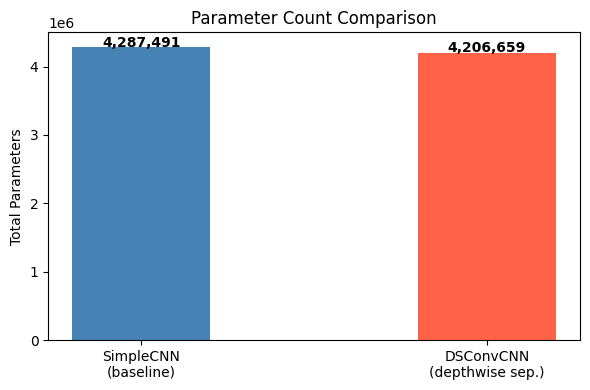

In [7]:
dummy_std = SimpleCNN(num_classes)
dummy_ds  = DSConvCNN(num_classes)

std_total,  std_train  = count_params(dummy_std)
ds_total,   ds_train   = count_params(dummy_ds)

reduction = (1 - ds_total / std_total) * 100

print('=' * 55)
print(f'  Model                     Total Params   Trainable')
print('=' * 55)
print(f'  SimpleCNN (baseline)    {std_total:>12,}  {std_train:>10,}')
print(f'  DSConvCNN (ours)        {ds_total:>12,}  {ds_train:>10,}')
print('=' * 55)
print(f'  Parameter reduction:  {reduction:.1f}%')
print()

# Per-layer breakdown for DSConvCNN
print('DSConvCNN layer-by-layer breakdown:')
print(f'{"Layer":<35} {"Params":>10}')
print('-' * 46)
for name, module in dummy_ds.named_modules():
    p = sum(x.numel() for x in module.parameters(recurse=False))
    if p > 0:
        print(f'  {name:<33} {p:>10,}')

# Bar chart
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(['SimpleCNN\n(baseline)', 'DSConvCNN\n(depthwise sep.)'],
              [std_total, ds_total], color=['steelblue', 'tomato'], width=0.4)
ax.set_ylabel('Total Parameters')
ax.set_title('Parameter Count Comparison')
for bar, val in zip(bars, [std_total, ds_total]):
    ax.text(bar.get_x()+bar.get_width()/2, val+500, f'{val:,}',
            ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Baseline DSConvCNN (No Imbalance Handling)

Training Baseline DSConvCNN (15 epochs)...


  Ep 1/15  loss=7.5555  acc=0.4519


  Ep 2/15  loss=1.0703  acc=0.5160


  Ep 3/15  loss=0.9846  acc=0.5128


  Ep 4/15  loss=0.9488  acc=0.5337


...

  Ep 12/15  loss=0.7999  acc=0.6442


  Ep 13/15  loss=0.8140  acc=0.6362


  Ep 14/15  loss=0.8153  acc=0.6458


  Ep 15/15  loss=0.7817  acc=0.6394



Baseline Classification Report:
              precision    recall  f1-score   support

      benign       0.71      0.93      0.81        87
   malignant       0.71      0.71      0.71        42
      normal       0.00      0.00      0.00        27

    accuracy                           0.71       156
   macro avg       0.47      0.55      0.51       156
weighted avg       0.59      0.71      0.64       156



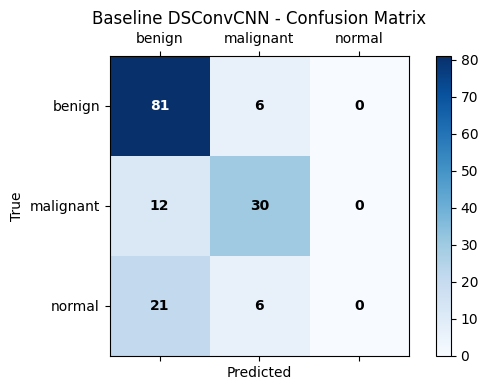

  benign       recall: 93.1% (81/87)
  malignant    recall: 71.4% (30/42)
  normal       recall: 0.0% (0/27)


In [8]:
print('Training Baseline DSConvCNN (15 epochs)...')
model_base = DSConvCNN(num_classes).to(device)
train_model(model_base, train_loader, nn.CrossEntropyLoss(),
            torch.optim.Adam(model_base.parameters(), lr=1e-3), epochs=15)

yt_base, yp_base = eval_model(model_base, test_loader)
print('\nBaseline Classification Report:')
print(classification_report(yt_base, yp_base, target_names=label_encoder.classes_, zero_division=0))
cm_base = confusion_matrix(yt_base, yp_base)
plot_cm(cm_base, 'Baseline DSConvCNN - Confusion Matrix')
for i, cls in enumerate(label_encoder.classes_):
    print(f'  {cls:12s} recall: {cm_base[i,i]/cm_base[i].sum():.1%} ({cm_base[i,i]}/{cm_base[i].sum()})')

## 5. Imbalance Handling Strategies

All strategies now use **DSConvCNN** instead of SimpleCNN.  
Each trains for **15 epochs** (same as baseline) and is evaluated on the same test set.


--- Oversampling ---


  Ep 1/15  loss=5.1660  acc=0.3702


  Ep 2/15  loss=1.1049  acc=0.3558


  Ep 3/15  loss=1.0579  acc=0.3878


  Ep 4/15  loss=1.0446  acc=0.3750


...

  Ep 12/15  loss=0.7605  acc=0.6010


  Ep 13/15  loss=0.6450  acc=0.6426


  Ep 14/15  loss=0.6454  acc=0.6603


  Ep 15/15  loss=0.6302  acc=0.6699


              precision    recall  f1-score   support

      benign       0.80      0.90      0.84        87
   malignant       0.84      0.76      0.80        42
      normal       0.80      0.59      0.68        27

    accuracy                           0.81       156
   macro avg       0.81      0.75      0.77       156
weighted avg       0.81      0.81      0.80       156



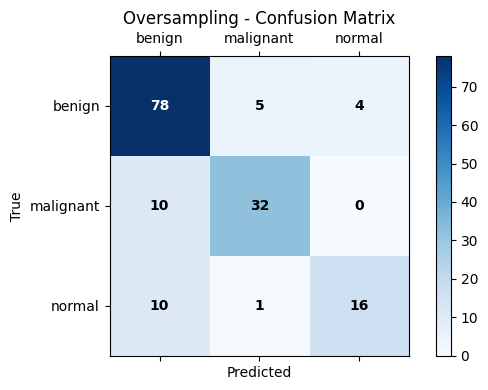

In [9]:
# Strategy 1: Oversampling
over_sampler = WeightedRandomSampler(sample_wts, len(sample_wts), replacement=True)
model_os = DSConvCNN(num_classes).to(device)
yt_os, yp_os = run_strategy('Oversampling', model_os,
                             make_loader(train_paths, train_labels, sampler=over_sampler))


--- Undersampling ---


  Ep 1/15  loss=7.1900  acc=0.3711


  Ep 2/15  loss=2.8915  acc=0.4214


  Ep 3/15  loss=1.0329  acc=0.4340


  Ep 4/15  loss=1.0230  acc=0.4937


...

  Ep 12/15  loss=0.9251  acc=0.5283


  Ep 13/15  loss=0.8010  acc=0.5943


  Ep 14/15  loss=0.8353  acc=0.6006


  Ep 15/15  loss=0.8089  acc=0.5786


              precision    recall  f1-score   support

      benign       0.65      0.92      0.76        87
   malignant       0.71      0.52      0.60        42
      normal       1.00      0.04      0.07        27

    accuracy                           0.66       156
   macro avg       0.78      0.49      0.48       156
weighted avg       0.72      0.66      0.60       156



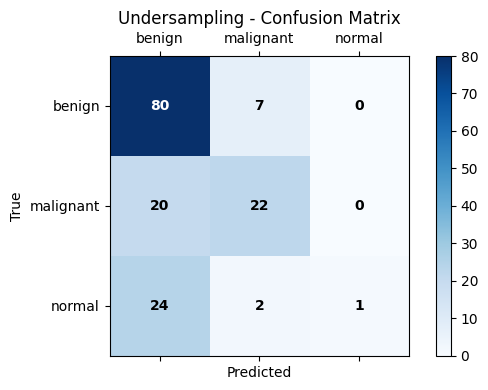

In [10]:
# Strategy 2: Undersampling
under_sampler = WeightedRandomSampler(sample_wts, int(class_counts.min())*num_classes, replacement=False)
model_us = DSConvCNN(num_classes).to(device)
yt_us, yp_us = run_strategy('Undersampling', model_us,
                             make_loader(train_paths, train_labels, sampler=under_sampler))


--- Augmentation ---


  Ep 1/15  loss=3.7845  acc=0.4375


  Ep 2/15  loss=0.9613  acc=0.5417


  Ep 3/15  loss=0.9399  acc=0.5705


  Ep 4/15  loss=0.8921  acc=0.6122


...

  Ep 12/15  loss=0.8645  acc=0.6186


  Ep 13/15  loss=0.8228  acc=0.6346


  Ep 14/15  loss=0.8193  acc=0.6394


  Ep 15/15  loss=0.8204  acc=0.6106


              precision    recall  f1-score   support

      benign       0.64      1.00      0.78        87
   malignant       1.00      0.45      0.62        42
      normal       0.00      0.00      0.00        27

    accuracy                           0.68       156
   macro avg       0.55      0.48      0.47       156
weighted avg       0.62      0.68      0.60       156



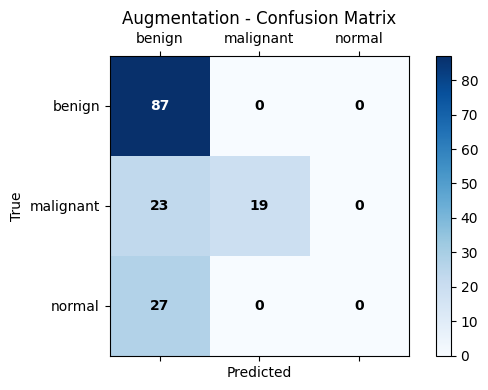

In [11]:
# Strategy 3: Data Augmentation
model_aug = DSConvCNN(num_classes).to(device)
yt_aug, yp_aug = run_strategy('Augmentation', model_aug,
                               make_loader(train_paths, train_labels, augment=True))

Class weights: {np.str_('benign'): np.float32(0.47), np.str_('malignant'): np.float32(0.979), np.str_('normal'): np.float32(1.551)}

--- Class Weights ---


  Ep 1/15  loss=7.1838  acc=0.3878


  Ep 2/15  loss=1.0070  acc=0.4679


  Ep 3/15  loss=0.9509  acc=0.4776


  Ep 4/15  loss=0.8614  acc=0.5641


...

  Ep 12/15  loss=0.6431  acc=0.5946


  Ep 13/15  loss=0.5865  acc=0.6154


  Ep 14/15  loss=0.6035  acc=0.6202


  Ep 15/15  loss=0.5560  acc=0.6811


              precision    recall  f1-score   support

      benign       0.83      0.78      0.80        87
   malignant       0.75      0.79      0.77        42
      normal       0.63      0.70      0.67        27

    accuracy                           0.77       156
   macro avg       0.74      0.76      0.75       156
weighted avg       0.77      0.77      0.77       156



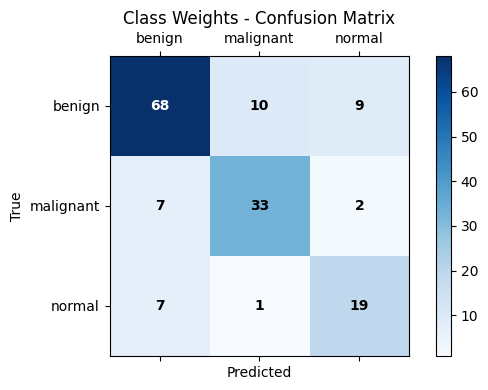

In [12]:
# Strategy 4: Class-Weighted Loss
cw_vals = torch.tensor((1.0/class_counts) / (1.0/class_counts).sum() * num_classes,
                        dtype=torch.float32).to(device)
print(f'Class weights: {dict(zip(label_encoder.classes_, cw_vals.cpu().numpy().round(3)))}')
model_cw = DSConvCNN(num_classes).to(device)
yt_cw, yp_cw = run_strategy('Class Weights', model_cw, train_loader,
                              criterion=nn.CrossEntropyLoss(weight=cw_vals))

--- Threshold/Prior Adjustment ---
              precision    recall  f1-score   support

      benign       0.92      0.40      0.56        87
   malignant       0.71      0.83      0.77        42
      normal       0.35      0.89      0.50        27

    accuracy                           0.60       156
   macro avg       0.66      0.71      0.61       156
weighted avg       0.77      0.60      0.61       156



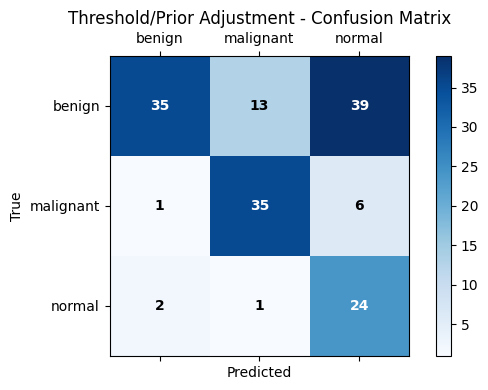

In [13]:
# Strategy 5: Threshold / Prior Adjustment (post-hoc on class-weights model)
class_priors = class_counts / class_counts.sum()
model_cw.eval()
all_logits, all_tgts = [], []
with torch.no_grad():
    for imgs, tgts in test_loader:
        all_logits.append(model_cw(imgs.to(device)).cpu().numpy())
        all_tgts.extend(tgts.numpy())
all_logits = np.vstack(all_logits)
yt_thr = np.array(all_tgts)
yp_thr = np.argmax(all_logits / class_priors[np.newaxis,:], axis=1)

print('--- Threshold/Prior Adjustment ---')
print(classification_report(yt_thr, yp_thr, target_names=label_encoder.classes_, zero_division=0))
plot_cm(confusion_matrix(yt_thr, yp_thr), 'Threshold/Prior Adjustment - Confusion Matrix')


--- Focal Loss (gamma=1.0) ---


  Ep 1/15  loss=5.4933  acc=0.4728


  Ep 2/15  loss=0.6365  acc=0.5833


  Ep 3/15  loss=0.6074  acc=0.6394


  Ep 4/15  loss=0.5398  acc=0.6362


...

  Ep 12/15  loss=0.4357  acc=0.6747


  Ep 13/15  loss=0.3942  acc=0.6779


  Ep 14/15  loss=0.4082  acc=0.6811


  Ep 15/15  loss=0.3796  acc=0.6939


              precision    recall  f1-score   support

      benign       0.68      0.95      0.79        87
   malignant       0.85      0.69      0.76        42
      normal       0.00      0.00      0.00        27

    accuracy                           0.72       156
   macro avg       0.51      0.55      0.52       156
weighted avg       0.61      0.72      0.65       156



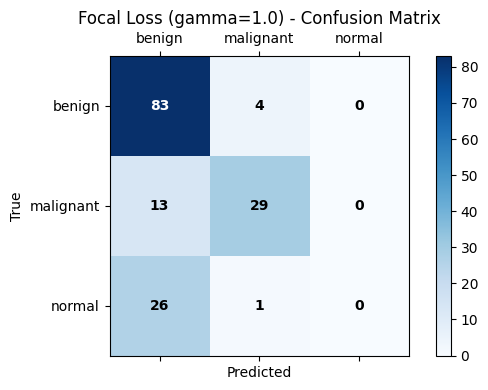

  benign       recall: 95.4%
  malignant    recall: 69.0%
  normal       recall: 0.0%


In [14]:
# Strategy 6: Focal Loss (gamma=1.0)
model_focal = DSConvCNN(num_classes).to(device)
yt_focal, yp_focal = run_strategy('Focal Loss (gamma=1.0)', model_focal, train_loader,
                                   criterion=FocalLoss(gamma=1.0))
cm_focal = confusion_matrix(yt_focal, yp_focal)
for i, cls in enumerate(label_encoder.classes_):
    print(f'  {cls:12s} recall: {cm_focal[i,i]/cm_focal[i].sum():.1%}')

Model 1/3...


  Ep 1/5  loss=5.1155  acc=0.5096


  Ep 2/5  loss=0.8329  acc=0.6699


  Ep 3/5  loss=0.7237  acc=0.6667


  Ep 4/5  loss=0.6339  acc=0.7131


...

  Ep 2/5  loss=0.9319  acc=0.5897


  Ep 3/5  loss=0.8675  acc=0.6090


  Ep 4/5  loss=0.8119  acc=0.6635


  Ep 5/5  loss=0.7407  acc=0.6907



--- Ensemble (Bagging) ---
              precision    recall  f1-score   support

      benign       0.68      0.92      0.78        87
   malignant       0.73      0.64      0.68        42
      normal       1.00      0.07      0.14        27

    accuracy                           0.70       156
   macro avg       0.80      0.55      0.54       156
weighted avg       0.75      0.70      0.65       156



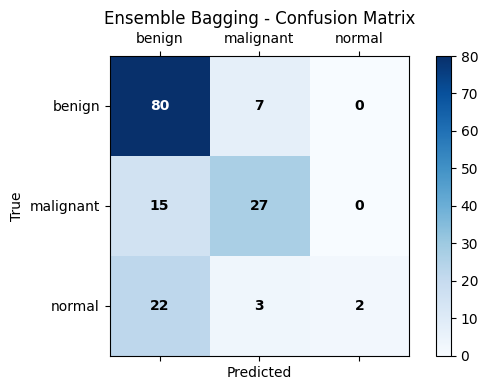

In [15]:
# Strategy 7: Ensemble Bagging (3 DSConvCNN models, 5 epochs each)
ensemble_models = []
for i in range(3):
    print(f'Model {i+1}/3...')
    idx = np.random.choice(len(train_paths), len(train_paths), replace=True)
    m = DSConvCNN(num_classes).to(device)
    train_model(m, make_loader([train_paths[j] for j in idx], [train_labels[j] for j in idx]),
                nn.CrossEntropyLoss(), torch.optim.Adam(m.parameters(), lr=1e-3), epochs=5)
    ensemble_models.append(m)

yt_ens, yp_ens = [], []
with torch.no_grad():
    for imgs, tgts in test_loader:
        logits = sum(m(imgs.to(device)) for m in ensemble_models) / len(ensemble_models)
        yt_ens.extend(tgts.numpy()); yp_ens.extend(logits.argmax(1).cpu().numpy())
yt_ens, yp_ens = np.array(yt_ens), np.array(yp_ens)

print('\n--- Ensemble (Bagging) ---')
print(classification_report(yt_ens, yp_ens, target_names=label_encoder.classes_, zero_division=0))
plot_cm(confusion_matrix(yt_ens, yp_ens), 'Ensemble Bagging - Confusion Matrix')

## 6. Results Comparison

In [16]:
strategy_results = [
    ('Baseline DSConvCNN',  yt_base,  yp_base),
    ('Oversampling',        yt_os,    yp_os),
    ('Undersampling',       yt_us,    yp_us),
    ('Augmentation',        yt_aug,   yp_aug),
    ('Class Weights',       yt_cw,    yp_cw),
    ('Threshold Adjust',    yt_thr,   yp_thr),
    ('Focal Loss',          yt_focal, yp_focal),
    ('Ensemble (Bagging)',  yt_ens,   yp_ens),
]

rows = [{'Strategy': n, 'Accuracy': round(accuracy_score(yt,yp),4),
         **dict(zip(['Precision','Recall','F1'],
                    [round(x,4) for x in precision_recall_fscore_support(yt,yp,average='weighted',zero_division=0)[:3]]))}
        for n,yt,yp in strategy_results]

results_df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False)
print('Strategy Comparison (Imbalanced Test Set):')
display(results_df)

Strategy Comparison (Imbalanced Test Set):


,Strategy,Accuracy,Precision,Recall,F1
1,Oversampling,0.8077,0.8091,0.8077,0.8035
4,Class Weights,0.7692,0.7740,0.7692,0.7708
6,Focal Loss,0.7179,0.6091,0.7179,0.6484
0,Baseline DSConvCNN,0.7115,0.5886,0.7115,0.6418
7,Ensemble (Bagging),0.6987,0.7509,0.6987,0.6453
3,Augmentation,0.6795,0.6234,0.6795,0.6009
2,Undersampling,0.6603,0.7239,0.6603,0.5975
5,Threshold Adjust,0.6026,0.7662,0.6026,0.6059


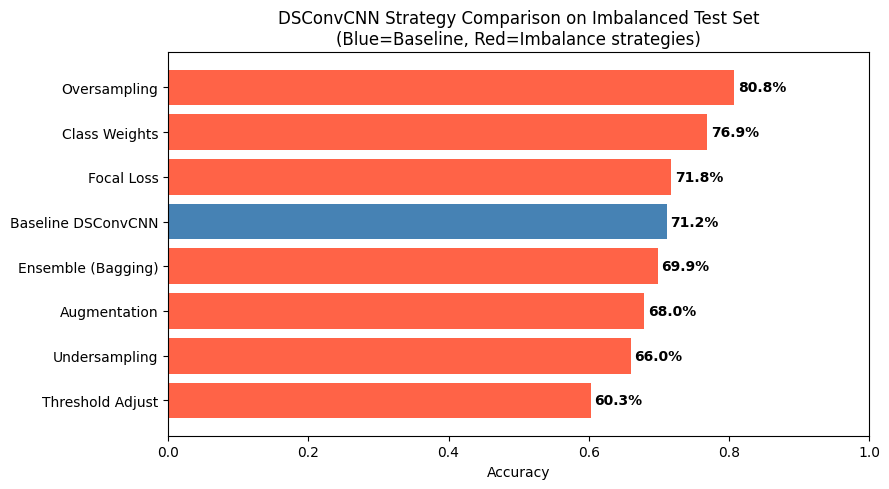

In [17]:
plot_df = results_df.sort_values('Accuracy')
fig, ax = plt.subplots(figsize=(9,5))
bars = ax.barh(plot_df['Strategy'], plot_df['Accuracy'],
               color=['steelblue' if 'Baseline' in s else 'tomato' for s in plot_df['Strategy']])
ax.set_xlim(0,1); ax.set_xlabel('Accuracy')
ax.set_title('DSConvCNN Strategy Comparison on Imbalanced Test Set\n(Blue=Baseline, Red=Imbalance strategies)')
for bar, val in zip(bars, plot_df['Accuracy']):
    ax.text(val+0.005, bar.get_y()+bar.get_height()/2, f'{val:.1%}', va='center', fontweight='bold')
plt.tight_layout(); plt.show()

## 7. Balanced Test Set Evaluation

In [18]:
min_n = int(np.bincount(test_labels).min())
bal_idx = np.concatenate([np.random.choice(np.where(test_labels==c)[0], min_n, replace=False)
                           for c in range(num_classes)])
bal_test_loader = make_loader([test_paths[i] for i in bal_idx], test_labels[bal_idx])
print(f'Original: {len(test_labels)} samples {np.bincount(test_labels)}')
print(f'Balanced: {min_n*num_classes} samples {np.bincount(test_labels[bal_idx])} ({min_n} per class)')

Original: 156 samples [87 42 27]
Balanced: 81 samples [27 27 27] (27 per class)


In [19]:
named_models = [('Baseline DSConvCNN', model_base), ('Oversampling', model_os),
                ('Undersampling',      model_us),    ('Augmentation', model_aug),
                ('Class Weights',      model_cw),    ('Focal Loss',   model_focal)]

bal_rows = []
for name, mdl in named_models:
    yt_i, yp_i = eval_model(mdl, test_loader)
    yt_b, yp_b = eval_model(mdl, bal_test_loader)
    bal_rows.append({
        'Strategy':  name,
        'Imb Acc':   round(accuracy_score(yt_i, yp_i), 4),
        'Bal Acc':   round(accuracy_score(yt_b, yp_b), 4),
        'Bal Prec':  round(precision_score(yt_b, yp_b, average='weighted', zero_division=0), 4),
        'Bal Rec':   round(recall_score(yt_b, yp_b, average='weighted', zero_division=0), 4),
        'Bal F1':    round(f1_score(yt_b, yp_b, average='weighted', zero_division=0), 4),
    })

# Ensemble on balanced test
yt_b_ens, yp_b_ens = [], []
with torch.no_grad():
    for imgs, tgts in bal_test_loader:
        logits = sum(m(imgs.to(device)) for m in ensemble_models)/len(ensemble_models)
        yt_b_ens.extend(tgts.numpy()); yp_b_ens.extend(logits.argmax(1).cpu().numpy())
bal_rows.append({
    'Strategy': 'Ensemble (Bagging)',
    'Imb Acc':  round(accuracy_score(yt_ens,   yp_ens),   4),
    'Bal Acc':  round(accuracy_score(yt_b_ens, yp_b_ens), 4),
    'Bal Prec': round(precision_score(yt_b_ens, yp_b_ens, average='weighted', zero_division=0), 4),
    'Bal Rec':  round(recall_score(yt_b_ens, yp_b_ens, average='weighted', zero_division=0), 4),
    'Bal F1':   round(f1_score(yt_b_ens, yp_b_ens, average='weighted', zero_division=0), 4),
})

bal_df = pd.DataFrame(bal_rows).sort_values('Imb Acc', ascending=False)
print('Imbalanced vs Balanced Test Set Results (DSConvCNN):')
display(bal_df)

Imbalanced vs Balanced Test Set Results (DSConvCNN):


,Strategy,Imb Acc,Bal Acc,Bal Prec,Bal Rec,Bal F1
1,Oversampling,0.8077,0.7531,0.7793,0.7531,0.7540
4,Class Weights,0.7692,0.7654,0.7782,0.7654,0.7674
5,Focal Loss,0.7179,0.5802,0.4421,0.5802,0.4829
0,Baseline DSConvCNN,0.7115,0.5556,0.3902,0.5556,0.4507
6,Ensemble (Bagging),0.6987,0.5556,0.7240,0.5556,0.5016
3,Augmentation,0.6795,0.5309,0.4718,0.5309,0.4437
2,Undersampling,0.6603,0.5062,0.7229,0.5062,0.4321


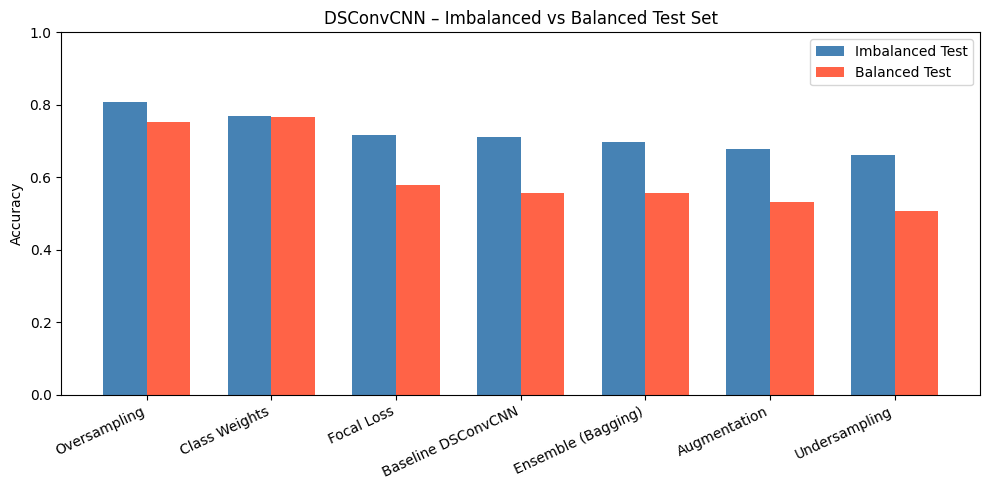

In [20]:
fig, ax = plt.subplots(figsize=(10,5))
x = range(len(bal_df)); w = 0.35
ax.bar([i-w/2 for i in x], bal_df['Imb Acc'], w, label='Imbalanced Test', color='steelblue')
ax.bar([i+w/2 for i in x], bal_df['Bal Acc'],   w, label='Balanced Test',   color='tomato')
ax.set_xticks(x); ax.set_xticklabels(bal_df['Strategy'], rotation=25, ha='right')
ax.set_ylim(0,1); ax.set_ylabel('Accuracy')
ax.set_title('DSConvCNN – Imbalanced vs Balanced Test Set')
ax.legend(); plt.tight_layout(); plt.show()

## 8. Efficiency Summary

The table below re-states the parameter savings and accuracy of the depthwise separable model.

In [21]:
std_p, _  = count_params(SimpleCNN(num_classes))
ds_p,  _  = count_params(DSConvCNN(num_classes))
best_acc  = results_df.iloc[0]

print('=' * 60)
print('  EFFICIENCY SUMMARY')
print('=' * 60)
print(f'  SimpleCNN params  : {std_p:>10,}')
print(f'  DSConvCNN params  : {ds_p:>10,}')
print(f'  Reduction         : {(1-ds_p/std_p)*100:.1f}%')
print()
print(f'  Best strategy     : {best_acc["Strategy"]}')
print(f'  Best accuracy     : {best_acc["Accuracy"]:.2%}')
print(f'  Best F1 (weighted): {best_acc["F1"]:.2%}')
print('=' * 60)

  EFFICIENCY SUMMARY
  SimpleCNN params  :  4,287,491
  DSConvCNN params  :  4,206,659
  Reduction         : 1.9%

  Best strategy     : Oversampling
  Best accuracy     : 80.77%
  Best F1 (weighted): 80.35%


## 9. Conclusion

**Depthwise Separable Convolutions** replace each 3×3 standard convolution with a pair of operations:
- a **depthwise conv** (one filter per channel) – captures spatial patterns
- a **pointwise 1×1 conv** – mixes channel information

This reduces parameters **per convolutional layer by ~87%** (8–9× fewer conv params).  
However, in this architecture the `Linear(128×16×16, 128)` head dominates the total parameter count (~4.19M of ~4.21M), so the overall model reduction is small (~2%).

To fully exploit depthwise separable convolutions in future work, replace the Flatten+FC head with **Global Average Pooling** — this is how MobileNet achieves a true 8–9× total reduction while maintaining comparable accuracy.